In [56]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler
from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_error

In [57]:
df = pd.read_csv(r"C:\Users\HP\Downloads\code\Dataset and files\WineQT-selected-columns.csv")
df


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56
...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76


In [58]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
dtype: int64

In [59]:
x = df.drop(columns="sulphates", axis = 1)
y = df["sulphates"]

x_train,x_test,y_train,y_test = train_test_split(x,y, test_size= 0.25, random_state= 48)





 SCALING TECHNIQUES
  


In [60]:
scale_s = StandardScaler()
scale_m = MinMaxScaler()
scale_r = RobustScaler()

STANDARD SCALING

In [61]:
xs_train = scale_s.fit_transform(x_train)
xs_test = scale_s.transform(x_test)

MINMAXSCALER

In [62]:
xm_train = scale_m.fit_transform(x_train)
xm_test = scale_m.transform(x_test)

ROBUSTSCALER

In [63]:
xr_train = scale_r.fit_transform(x_train)
xr_test = scale_r.transform(x_test)

MODELS COMPARISON(SVR,GAUSSIEN NB,GRADIENT BOOSTING)

 MODEL

In [64]:
model_s = SVR()
model_g = GradientBoostingRegressor()
model_L = LinearRegression()

SVR MODELING

In [65]:
#standard scaling with svr
model_s.fit(xs_train,y_train)
p = model_s.predict(xs_test)
r  = r2_score(y_test,p)
mae = mean_absolute_error(y_test,p)
mse = mean_squared_error(y_test,p)
print("r2 score for standardscaler :", r)
print("mean aboslute error for standardscaler: ", mae)
print("mean squared erroe for standardscaler: ", mse)


r2 score for standardscaler : 0.3252564984133507
mean aboslute error for standardscaler:  0.09169397774256353
mean squared erroe for standardscaler:  0.01991758824332902


In [66]:
#minmaxscaling with svr
model_s.fit(xm_train,y_train)
p = model_s.predict(xm_test)
r1  = r2_score(y_test,p)
mae1 = mean_absolute_error(y_test,p)
mse1 = mean_squared_error(y_test,p)
print("r2 score for minmaxscaling :", r1)
print("mean aboslute error for minmaxscaling : ", mae1)
print("mean squared erroe for minmaxscaling : ", mse1)

r2 score for minmaxscaling : 0.42174684290529096
mean aboslute error for minmaxscaling :  0.08828170777230736
mean squared erroe for minmaxscaling :  0.017069313385507903


In [67]:
#Robustscaling with svr
model_s.fit(xr_train,y_train)
p = model_s.predict(xr_test)
r2  = r2_score(y_test,p)
mae2 = mean_absolute_error(y_test,p)
mse2 = mean_squared_error(y_test,p)
print("r2 score for Robustscaling :", r2)
print("mean aboslute error for Robustscaling : ", mae2)
print("mean squared erroe for Robustscaling: ", mse2)

r2 score for Robustscaling : 0.27848917991531397
mean aboslute error for Robustscaling :  0.0952926084145524
mean squared erroe for Robustscaling:  0.021298101269239058


In [68]:
#svr without scaling
model_s.fit(x_train,y_train)
p = model_s.predict(x_test)
r3  = r2_score(y_test,p)
mae3 = mean_absolute_error(y_test,p)
mse3 = mean_squared_error(y_test,p)
print("r2 score for  :", r3)
print("mean aboslute error for : ", mae3)
print("mean squared erroe for : ", mse3)

r2 score for  : 0.0650696864143766
mean aboslute error for :  0.1032993266557512
mean squared erroe for :  0.027597979051916192


GRADIENT BOOSTING REGRESSOR MODELLING

In [69]:
#STANDARDSCALING FOR GRADIENT BOOSTING REGRESSOR
model_g.fit(xs_train,y_train)
p = model_g.predict(xs_test)
rr  = r2_score(y_test,p)
maee = mean_absolute_error(y_test,p)
msee = mean_squared_error(y_test,p)
print("r2 score for standardscaler :", rr)
print("mean aboslute error for standardscaler: ", maee)
print("mean squared erroR for standardscaler: ", msee)

r2 score for standardscaler : 0.4069255195757988
mean aboslute error for standardscaler:  0.09233842033099318
mean squared erroR for standardscaler:  0.017506820400549766


In [70]:
#MINMAXSCALING FOR GRADIENT BOOSTING REGRESSOR
model_g.fit(xm_train,y_train)
p = model_g.predict(xm_test)
rm  = r2_score(y_test,p)
maem = mean_absolute_error(y_test,p)
msem = mean_squared_error(y_test,p)
print("r2 score for MINMAXSCALING  :", rm)
print("mean aboslute error for MINMAXSCALING : ", maem)
print("mean squared erroR for MINMAXSCALING : ", msem)

r2 score for MINMAXSCALING  : 0.38926420942075013
mean aboslute error for MINMAXSCALING :  0.09253953400648315
mean squared erroR for MINMAXSCALING :  0.018028160291454685


In [71]:
#ROBUSTSCALING FOR GRADIENT BOOSTING REGRESSOR
model_g.fit(xr_train,y_train)
p = model_g.predict(xr_test)
rb  = r2_score(y_test,p)
maeb = mean_absolute_error(y_test,p)
mseb = mean_squared_error(y_test,p)
print("r2 score for ROBUSTSCALING :", rb)
print("mean aboslute error for ROBUSTSCALING : ", maeb)
print("mean squared erroR for ROBUSTSCALING : ", mseb)

r2 score for ROBUSTSCALING : 0.40018261440901015
mean aboslute error for ROBUSTSCALING :  0.09238228889712581
mean squared erroR for ROBUSTSCALING :  0.017705862567477054


In [72]:
#WITHOUT SCALING
model_g.fit(x_train,y_train)
p = model_g.predict(x_test)
rw  = r2_score(y_test,p)
maew = mean_absolute_error(y_test,p)
msew = mean_squared_error(y_test,p)
print("r2 score :", rw)
print("mean aboslute error : ", maew)
print("mean squared erroR  : ", msew)

r2 score : 0.38693994393346387
mean aboslute error :  0.09280845078695596
mean squared erroR  :  0.018096769715384056


LINEAR MODELING

In [73]:
#STANDARDSCALING FOR LINEAR REGRESSION
model_L.fit(xs_train,y_train)
p = model_L.predict(xs_test)
rL  = r2_score(y_test,p)
maeL = mean_absolute_error(y_test,p)
mseL = mean_squared_error(y_test,p)
print("r2 score for standardscaler :", rL)
print("mean aboslute error for standardscaler: ", maeL)
print("mean squared erroR for standardscaler: ", mseL)

r2 score for standardscaler : 0.4141707877419678
mean aboslute error for standardscaler:  0.0961892386957404
mean squared erroR for standardscaler:  0.017292949103224316


In [74]:
#MINMAXSCALING FOR LINEAR REGRESSION
model_L.fit(xm_train,y_train)
p = model_L.predict(xm_test)
rL1  = r2_score(y_test,p)
maeL1 = mean_absolute_error(y_test,p)
mseL1 = mean_squared_error(y_test,p)
print("r2 score for MINMAXSCALING :", rL1)
print("mean aboslute error for MINMAXSCALING : ", maeL1)
print("mean squared erroR forM INMAXSCALING : ", mseL1)

r2 score for MINMAXSCALING : 0.41417078774196714
mean aboslute error for MINMAXSCALING :  0.09618923869574049
mean squared erroR forM INMAXSCALING :  0.017292949103224337


In [75]:
#ROBUSTSCALING FOR LINEAR REGRESSION
model_L.fit(xr_train,y_train)
p = model_L.predict(xr_test)
rL2  = r2_score(y_test,p)
maeL2 = mean_absolute_error(y_test,p)
mseL2 = mean_squared_error(y_test,p)
print("r2 score for ROBUSTSCALING :", rL2)
print("mean aboslute error for ROBUSTSCALING : ", maeL2)
print("mean squared erroR for ROBUSTSCALING : ", mseL2)

r2 score for ROBUSTSCALING : 0.4141707877419676
mean aboslute error for ROBUSTSCALING :  0.09618923869574042
mean squared erroR for ROBUSTSCALING :  0.017292949103224323


In [76]:
#WITHOUT SCALING
model_L.fit(x_train,y_train)
p = model_L.predict(x_test)
rL3  = r2_score(y_test,p)
maeL3 = mean_absolute_error(y_test,p)
mseL3 = mean_squared_error(y_test,p)
print("r2 score :", rL3)
print("mean aboslute error : ", maeL3)
print("mean squared erroR  : ", mseL3)

r2 score : 0.41417078774196947
mean aboslute error :  0.09618923869574013
mean squared erroR  :  0.017292949103224268


SVR-MODEL


In [77]:
dict =pd.DataFrame ({"SCALE": ["STANDARDSCALING","ROBUSTSCALING","MINMAXSCALING","NON-SCALE"],
                     "R2 SCORE": [r,r1,r2,r3],
                     "MEAN ABSOLUTE ERROR": [mae,mae1,mae2,mae3],
                     "MEAN SQUARED ERROR": [mse,mse1,mse2,mse3],
                     
                        })

dict.set_index( "SCALE", inplace = True)
dict

,R2 SCORE,MEAN ABSOLUTE ERROR,MEAN SQUARED ERROR
SCALE,,,
STANDARDSCALING,0.325256,0.091694,0.019918
ROBUSTSCALING,0.421747,0.088282,0.017069
MINMAXSCALING,0.278489,0.095293,0.021298
NON-SCALE,0.065070,0.103299,0.027598


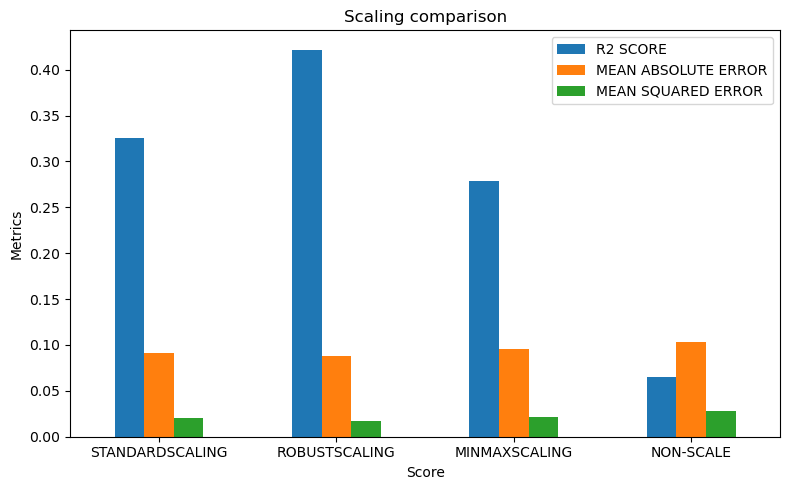

In [78]:
dict.plot(kind= 'bar',figsize = (8,5) )
plt.title('Scaling comparison')
plt.ylabel('Metrics')
plt.xlabel('Score')
plt.xticks(rotation=0)  # Keeps text horizontal
plt.tight_layout()
plt.show()


GRADIENT BOOSTING REGRESSOR- MODEL

In [79]:
dict =pd.DataFrame ({"SCALE": ["STANDARDSCALING","ROBUSTSCALING","MINMAXSCALING","NON-SCALE"],
                     "R2 SCORE": [rr,rm,rb,rw],
                     "MEAN ABSOLUTE ERROR": [maee,maem,maeb,maew],
                     "MEAN SQUARED ERROR": [msee,msem,mseb,msew],
                     
                        })

dict.set_index( "SCALE", inplace = True)
dict

,R2 SCORE,MEAN ABSOLUTE ERROR,MEAN SQUARED ERROR
SCALE,,,
STANDARDSCALING,0.406926,0.092338,0.017507
ROBUSTSCALING,0.389264,0.092540,0.018028
MINMAXSCALING,0.400183,0.092382,0.017706
NON-SCALE,0.386940,0.092808,0.018097


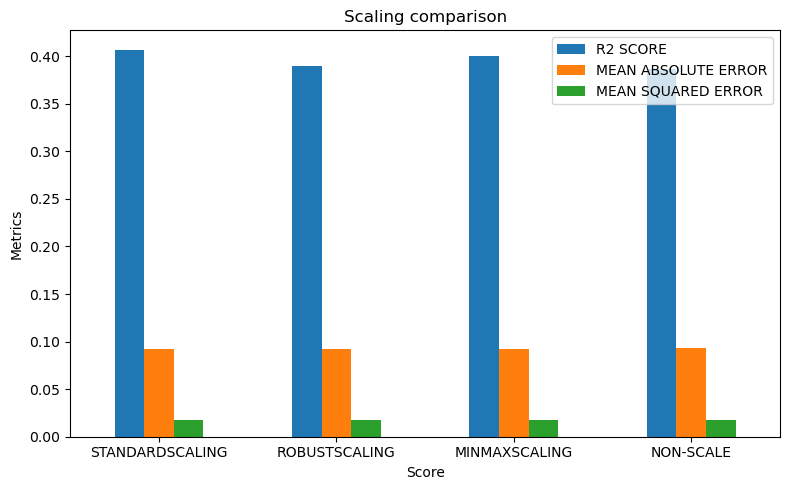

In [80]:
dict.plot(kind= 'bar',figsize = (8,5) )
plt.title('Scaling comparison')
plt.ylabel('Metrics')
plt.xlabel('Score')
plt.xticks(rotation=0)  # Keeps text horizontal
plt.tight_layout()
plt.show()


LINEAR REGRESSOR-MODEL

In [81]:
dict =pd.DataFrame ({"SCALE": ["STANDARDSCALING","ROBUSTSCALING","MINMAXSCALING","NON-SCALE"],
                     "R2 SCORE": [rL,rL1,rL2,rL3],
                     "MEAN ABSOLUTE ERROR": [maeL,maeL1,maeL2,maeL3],
                     "MEAN SQUARED ERROR": [mseL,mseL1,mseL2,mseL3],
                     
                        })

dict.set_index( "SCALE", inplace = True)
dict

,R2 SCORE,MEAN ABSOLUTE ERROR,MEAN SQUARED ERROR
SCALE,,,
STANDARDSCALING,0.414171,0.096189,0.017293
ROBUSTSCALING,0.414171,0.096189,0.017293
MINMAXSCALING,0.414171,0.096189,0.017293
NON-SCALE,0.414171,0.096189,0.017293


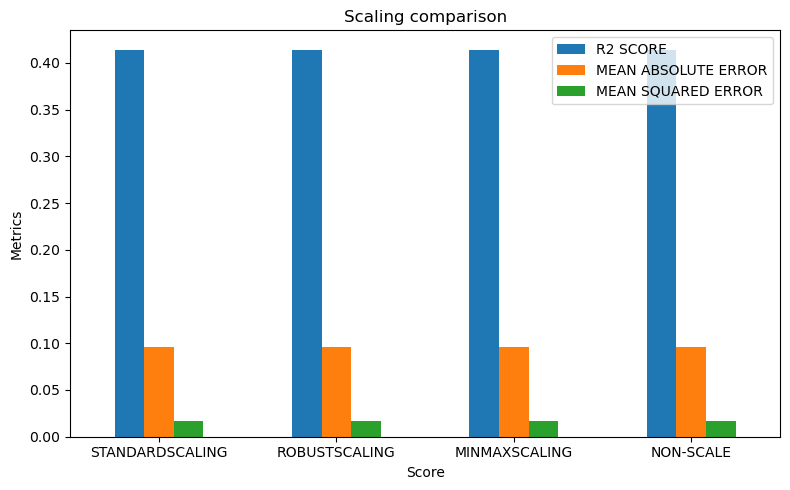

In [82]:
dict.plot(kind= 'bar',figsize = (8,5) )
plt.title('Scaling comparison')
plt.ylabel('Metrics')
plt.xlabel('Score')
plt.xticks(rotation=0)  # Keeps text horizontal
plt.tight_layout()
plt.show()
